<a href="https://colab.research.google.com/github/EJamdar05/cs276-project/blob/main/CS276_Project_Ukraine_Graph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stance to Region Graph
 This code will build a bipartite graph that contains stances to every region.

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

df = pd.read_csv('data/clean_data/output.csv')
df.head()

,tweet_id,lang,country,verified,sentiment_neutral,entail_prob,contra_prob,stance,region
0,1540451336876986373,cs,Slovakia,True,0.5044,0.30,0.70,unsure,Europe
1,1516696238212661253,ro,Italy,False,0.9146,0.18,0.82,unsure,Europe
2,1587766197298548738,te,India,True,0.5799,0.31,0.69,unsure,Asia
3,1586193152175529984,te,India,True,0.0000,0.03,0.97,unsure,Asia
4,1580452730212331520,te,India,True,0.0000,0.33,0.67,pro-Ukraine,Asia


In [2]:
B = nx.Graph()

stances = df["stance"].unique()
regions = df["region"].unique()

print(stances)
print(regions)

['unsure' 'pro-Ukraine' 'pro-Russia']
['Europe' 'Asia' 'North America' 'Africa' 'Middle East' 'Oceania'
 'South America']


# Bipartite Graph Building
Each node will be added from the unique stances and regions. From there, the connecting edges will be every tweet encoded with the features on the entra_prob and the contra_prob. For more significance in terms of weight, entra_prob is used as this is the determing factor for how strong a stance is. 

In [3]:
# define the bipartite graph
# build a region to stance graph (left is stance, right is region)
B = nx.MultiGraph()
B.add_nodes_from(stances, bipartite='stance')
B.add_nodes_from(regions, bipartite='region')

# add edges with weights
for index, row in df.iterrows():
    stance = row["stance"]
    region = row["region"]
    tweet_id = row["tweet_id"]
    entail_prob = row["entail_prob"]
    contra_prob = row["contra_prob"]
    weight = entail_prob 
    
    # add edge with tweet_id and the associated weight (entail_prob)
    B.add_edge(stance, region, weight=weight, tweet_id=tweet_id, 
               entail_prob=entail_prob, contra_prob=contra_prob)
    

# print the graph information
print(f"Nodes {B.number_of_nodes()}")
print(f"Edges {B.number_of_edges()}")



Nodes 10
Edges 646573


# Visualizng The Graph
For the sake of simplicity, the graph will condense down the edges to a count for each position for every country. Otherwise, the graph would have been to overwhelming to look at visually, 

/Users/eshaqjamdar/miniconda3/envs/struct2vec/lib/python3.9/site-packages/networkx/drawing/nx_pylab.py:305: UserWarning: 

The connectionstyle keyword argument is not applicable when drawing edges
with LineCollection.

To make this warning go away, either specify `arrows=True` to
force FancyArrowPatches or use the default value for connectionstyle.
Note that using FancyArrowPatches may be slow for large graphs.

  draw_networkx_edges(G, pos, arrows=arrows, **edge_kwds)


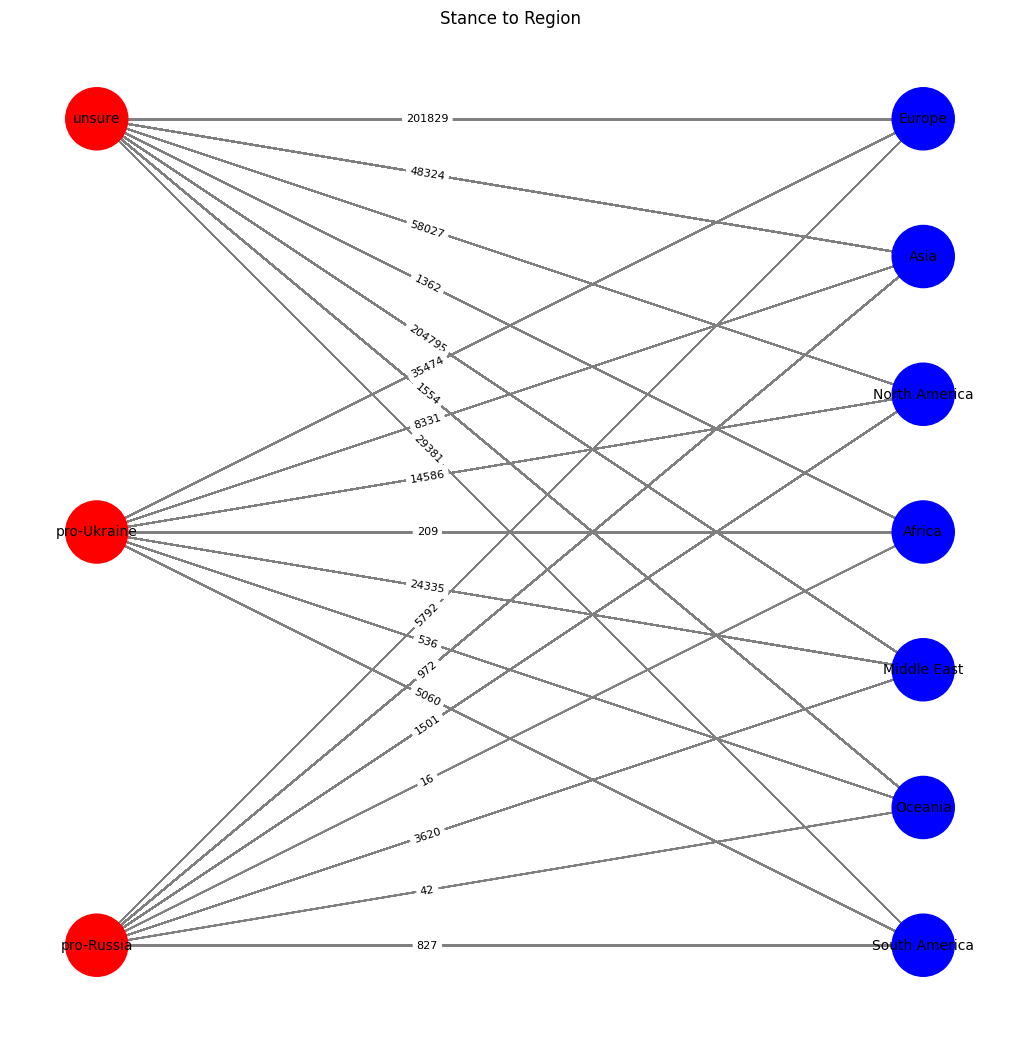

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# Define positions for the nodes
# Create a layout for the bipartite graph
pos = {}
stance_y = np.linspace(1, 0, len(stances)) * 10
region_y = np.linspace(1, 0, len(regions)) * 10

# left side
for i, node in enumerate(stances):
    pos[node] = (0, stance_y[i])
# right side
for i, node in enumerate(regions):
    pos[node] = (1, region_y[i])
plt.figure(figsize=(10, 10))

# Define colors for the nodes
# Use red for stances and blue for regions
node_colors = ['red' if node in stances else 'blue' for node in B.nodes()]
# Draw the graph
nx.draw(B, pos=pos, node_color=node_colors, with_labels=True, 
        node_size=2000, font_size=10, edge_color='gray', connectionstyle="arc3,rad=0.1")

# condense the edges into counts (less edges visually)
edge_counts = {}
for u, v, key in B.edges.keys():
    if (u,v) in edge_counts:
        edge_counts[(u, v)] += 1
    elif (v,u) in edge_counts:
        edge_counts[(v, u)] += 1
    else:
        edge_counts[(u, v)] = 1

nx.draw_networkx_edge_labels(B, pos=pos, edge_labels=edge_counts, font_size=8, label_pos=0.6)

plt.title("Stance to Region")
plt.axis('off')
plt.show()
nx.write_edgelist(B, "data/clean_data/region_stances_per_region.edgelist")


# Louvain Community Detection
Simple Louvain unsupervised training to obtain the region stances and alliances.

In [ ]:
import community as community_louvain

# Conduct community detection using Louvain and find the community structure
partition = community_louvain.best_partition(B, weight='weight')
num_communities = len(set(partition.values()))
print(f"Detected {num_communities} communities")

# from the partition, create a dictionary to store the nodes in each community
communities_dict = {}
for node, id in partition.items():
    if id not in communities_dict:
        communities_dict[id] = []
    communities_dict[id].append(node)

# Print the communities and their nodes
for community_id, nodes in communities_dict.items():
    stance_count = sum(1 for node in nodes if B.nodes[node]['bipartite'] == 'stance')
    region_count = sum(1 for node in nodes if B.nodes[node]['bipartite'] == 'region')
    print(f"Community {community_id}: {len(nodes)} nodes ({stance_count} stances, {region_count} regions)")
    print("Stances:", [node for node in nodes if B.nodes[node]['bipartite'] == 'stance'])
    print("Regions:", [node for node in nodes if B.nodes[node]['bipartite'] == 'region'])
modularity_score = community_louvain.modularity(partition, B, weight='weight')
print(f"Modularity Score: {modularity_score:.4f}")

Detected 2 communities
Community 1: 3 nodes (1 stances, 2 regions)
Stances: ['unsure']
Regions: ['Europe', 'Middle East']
Community 0: 7 nodes (2 stances, 5 regions)
Stances: ['pro-Ukraine', 'pro-Russia']
Regions: ['Asia', 'North America', 'Africa', 'Oceania', 'South America']
Modularity Score: -0.6420


# Visualizing the Louvain Communities

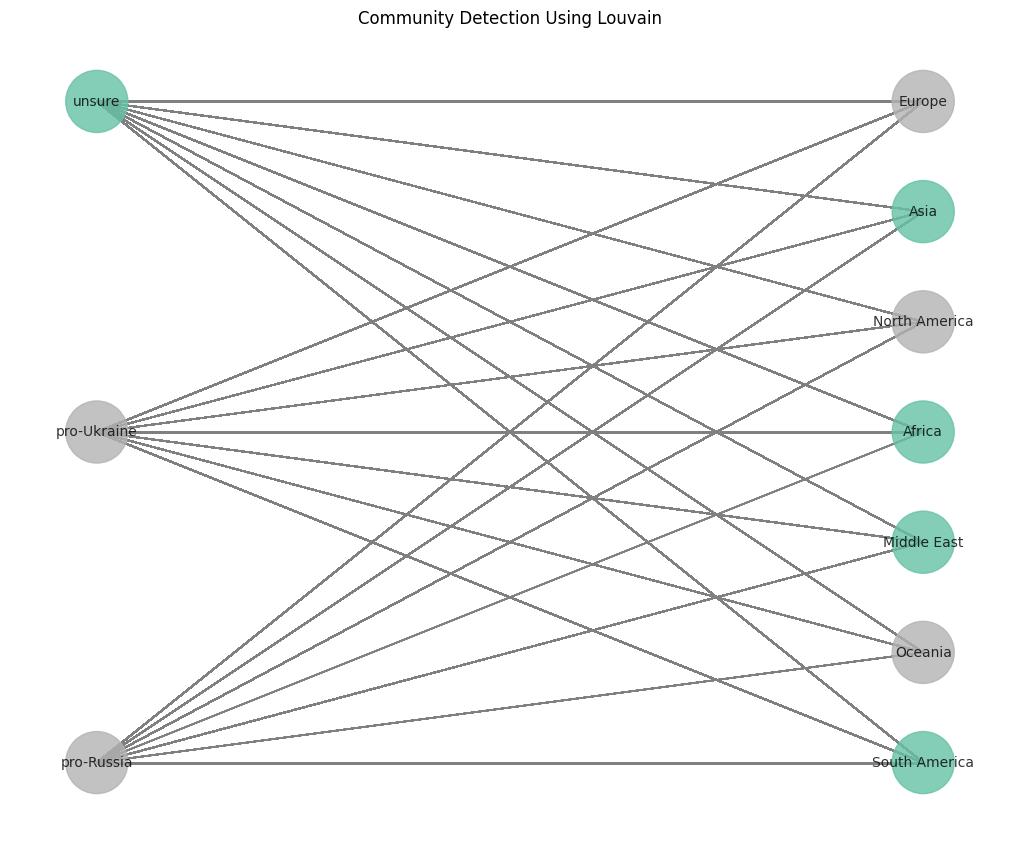

In [7]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

color_map = cm.get_cmap('Set2', max(partition.values()) + 1)
node_colors = [color_map(partition[node]) for node in B.nodes()]

plt.figure(figsize=(10,8))
nx.draw(
    B, pos=pos, node_color=node_colors, with_labels=True, edge_color="gray",
    node_size = 2000, font_size = 10, alpha = 0.8
)
plt.title("Community Detection Using Louvain")
plt.axis("off")
plt.show()


# Cosine Similarity and Node Embeddings
Using Node2Vec to generate random walks and then using cosine similarity to measure each region's most popular position

In [ ]:
from node2vec import Node2Vec
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np
# generate random walks and encourage exploration
node2vec = Node2Vec(B, dimensions=128, walk_length=80, num_walks=300, p=0.5, q=4, workers=4, weight_key='weight')
model = node2vec.fit(window=15, min_count=1)

# extract embeddings for the nodes
node_embeddings = {node: model.wv[node] for node in B.nodes()}
embedding_df = pd.DataFrame.from_dict(node_embeddings, orient='index')
region_embeddings = embedding_df.loc[regions]
stance_embeddings = embedding_df.loc[stances]

# get a cosine similarity for region and labeled stance
similarity_matrix = cosine_similarity(region_embeddings, stance_embeddings)
similarity_df = pd.DataFrame(similarity_matrix, index=region_embeddings.index, columns=stances)

# assign region to stance based on the highest similarity score
region_to_stance = {}
for region in similarity_df.index:
    assigned_stance = similarity_df.loc[region].idxmax()
    region_to_stance[region] = assigned_stance

# print the assigned stance for each region
for region, stance in region_to_stance.items():
    print(f"{region}: {stance}")

print(region_to_stance)

# calculate the mean inter-stance similarity and intra-stance similarity
inter_sim = []
intra_sim = []
for region in similarity_df.index:
    assigned_stance = region_to_stance[region]
    inter_sim.append(similarity_df.loc[region][assigned_stance])
    assigned_region = similarity_df[stance].idxmax()
    intra_sim.append(similarity_df.loc[assigned_region][stance])
mean_inter_score = sum(inter_sim) / len(inter_sim)
mean_intra_score = sum(intra_sim) / len(intra_sim)
print(f"Mean Inter Stance Similarity: {mean_inter_score}")
print(f"Mean Intra Stance Similarity: {mean_intra_score}")
separation_score = mean_intra_score - mean_inter_score
print(f"Mean Separation Score: {separation_score:.4f}")

Generating walks (CPU: 4): 100%|██████████| 75/75 [00:00<00:00, 1038.82it/s]


Europe: pro-Ukraine
Asia: unsure
North America: pro-Russia
Africa: pro-Ukraine
Middle East: pro-Ukraine
Oceania: pro-Russia
South America: unsure
{'Europe': 'pro-Ukraine', 'Asia': 'unsure', 'North America': 'pro-Russia', 'Africa': 'pro-Ukraine', 'Middle East': 'pro-Ukraine', 'Oceania': 'pro-Russia', 'South America': 'unsure'}
Mean Inter Stance Similarity: 0.7925287144524711
Mean Intra Stance Similarity: 0.8145737051963806
Mean Separation Score: 0.0220


# Node2Vec Embedding Visualization

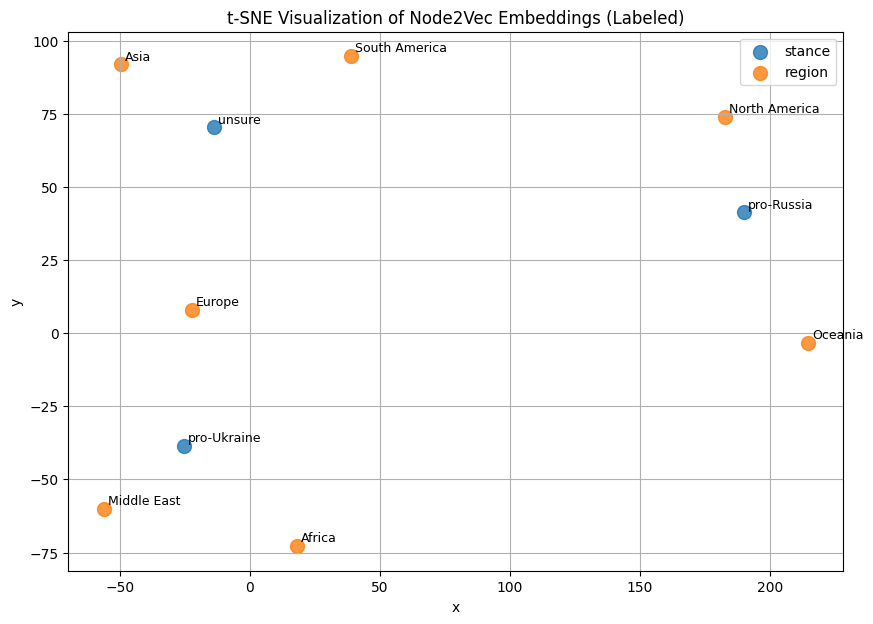

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

tsne = TSNE(n_components=2, random_state=42, perplexity=2)
embedding_2d = tsne.fit_transform(embedding_df.values)

embedding_2d_df = pd.DataFrame(embedding_2d, index=embedding_df.index, columns=['x', 'y'])
embedding_2d_df['type'] = ['stance' if node in stances else 'region' for node in embedding_2d_df.index]
embedding_2d_df['community'] = [partition[node] if node in partition else -1 for node in embedding_2d_df.index]

plt.figure(figsize=(10, 7))

for node_type in ['stance', 'region']:
    subset = embedding_2d_df[embedding_2d_df['type'] == node_type]
    plt.scatter(subset['x'], subset['y'], label=node_type, s=100, alpha=0.8)

for node, row in embedding_2d_df.iterrows():
    plt.text(row['x'] + 1.5, row['y'] + 1.5, node, fontsize=9)  

plt.title("t-SNE Visualization of Node2Vec Embeddings (Labeled)")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()



# Heatmap For Cosine Simularity of Each Region's Standing for Each Stance

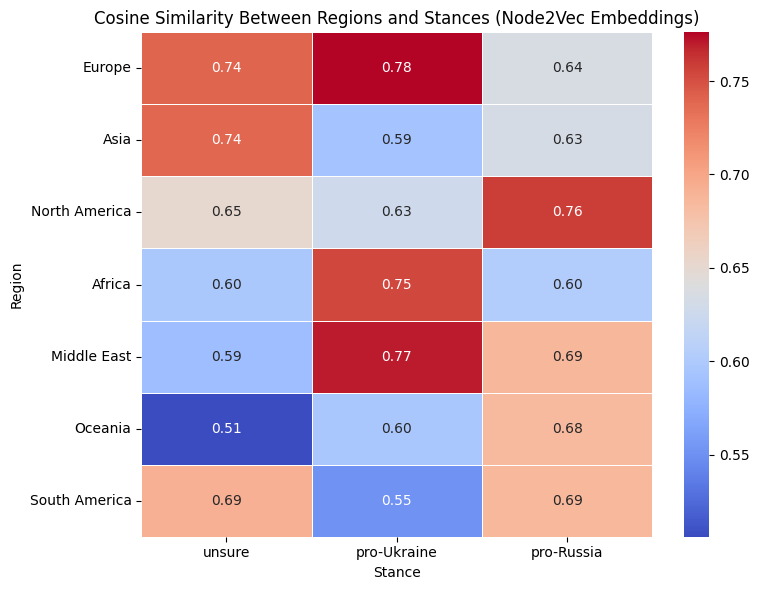

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(similarity_df, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Cosine Similarity Between Regions and Stances (Node2Vec Embeddings)")
plt.xlabel("Stance")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

